# Yellow Taxi Trip Records EDA

**Dataset:** NYC TLC Yellow Taxi Trip Records, January 2024  
**Source:** https://d37ci6vzurychx.cloudfront.net/trip-data  
**Data Dictionary:** https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf  
**Dictionary version reviewed:** March 18, 2025

## Notebook structure

1. Introduction
2. Dataset overview
3. Initial profiling
4. Validation against the official TLC Data Dictionary
5. Exploratory Data Analysis
6. Final findings
7. Cleaning handoff


## 1. Introduction

This notebook documents the exploratory analysis of the January 2024
NYC TLC Yellow Taxi Trip Records.

The purpose of the analysis is to understand the source data, compare
observed values with the official TLC documentation, test data-quality
hypotheses and produce recommendations for the next
processing stage.

The raw source data is not overwritten in this notebook. Derived
analytical fields are created only to support the investigation.

## 2. Dataset overview

### 2.1 Setup and data loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent

FILE_PATH = PROJECT_DIR / "data/raw_download/yellow_tripdata_2024-01.parquet"

print(FILE_PATH)
print("File exists:", FILE_PATH.exists())

if not FILE_PATH.exists():
    raise FileNotFoundError(FILE_PATH)

file_size_mb = FILE_PATH.stat().st_size / 1024**2
print(f"Size: {file_size_mb:.2f} MB")


/Users/jakub/Documents/Programowanie/Python/nyc_tlc_trip_data/data/raw_download/yellow_tripdata_2024-01.parquet
File exists: True
Size: 47.65 MB


In [3]:
df = pd.read_parquet(FILE_PATH)


### 2.2 Dataset structure

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(df.columns.tolist())
df.head()


Rows: 2,964,624
Columns: 19
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [5]:
df.dtypes


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

### Columns

The descriptions below follow the official TLC Yellow Taxi Trip Records
data dictionary. The dtypes are the types observed after loading this
January 2024 Parquet file with pandas.

Name | Observed dtype | Official meaning
--- | --- | ---
`VendorID` | `int32` | Code identifying the TPEP provider that supplied the record.
`tpep_pickup_datetime` | `datetime64[us]` | Date and time when the taximeter was engaged.
`tpep_dropoff_datetime` | `datetime64[us]` | Date and time when the taximeter was disengaged.
`passenger_count` | `float64` | Number of passengers in the vehicle.
`trip_distance` | `float64` | Elapsed trip distance in miles as reported by the taximeter.
`RatecodeID` | `float64` | Final rate code in effect at the end of the trip.
`store_and_fwd_flag` | `str` | Indicates whether the record was temporarily held in vehicle memory before being sent to the vendor because no server connection was available.
`PULocationID` | `int32` | TLC Taxi Zone in which the taximeter was engaged.
`DOLocationID` | `int32` | TLC Taxi Zone in which the taximeter was disengaged.
`payment_type` | `int64` | Numeric code indicating how the passenger paid for the trip.
`fare_amount` | `float64` | Time-and-distance fare calculated by the meter.
`extra` | `float64` | Miscellaneous extras and surcharges.
`mta_tax` | `float64` | Tax automatically triggered according to the metered rate in use.
`tip_amount` | `float64` | Credit-card tip recorded automatically; cash tips are not included.
`tolls_amount` | `float64` | Total amount of all tolls paid during the trip.
`improvement_surcharge` | `float64` | Improvement surcharge assessed at flag drop; this surcharge began in 2015.
`total_amount` | `float64` | Total amount charged to the passenger, excluding cash tips.
`congestion_surcharge` | `float64` | Total NYS congestion surcharge collected for the trip.
`Airport_fee` | `float64` | Airport pickup fee for LaGuardia or John F. Kennedy Airport.

The current dictionary spells the last field `airport_fee`, while the
January 2024 source file uses `Airport_fee`. The notebook preserves the
source column name.


### Initial structural conclusions

The dataset was loaded successfully and contains 2,964,624 rows and
19 columns. Timestamp fields were correctly parsed as datetimes.

Several identifier and categorical fields use numeric dtypes. 

`float64` dtype in some code columns is compatible with the presence
of missing values. 

`PULocationID` and `DOLocationID` are TLC Taxi Zone identifiers, not geographic coordinates.

## 3. Initial profiling

### 3.1 Missingness and basic profile

In [6]:
profile = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique_including_na": df.nunique(dropna=False),
})

profile


,dtype,missing,missing_%,unique_including_na
VendorID,int32,0,0.00,3
tpep_pickup_datetime,datetime64[us],0,0.00,1575706
tpep_dropoff_datetime,datetime64[us],0,0.00,1574780
passenger_count,float64,140162,4.73,11
trip_distance,float64,0,0.00,4489
RatecodeID,float64,140162,4.73,8
store_and_fwd_flag,str,140162,4.73,3
PULocationID,int32,0,0.00,260
DOLocationID,int32,0,0.00,261
payment_type,int64,0,0.00,5


In [7]:
metric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
]

df[metric_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
passenger_count,2824462.0,1.339281,0.850282,0.00,1.00,1.00,1.00,9.00
trip_distance,2964624.0,3.652169,225.462572,0.00,1.00,1.68,3.11,312722.30
fare_amount,2964624.0,18.175062,18.949548,-899.00,8.60,12.80,20.50,5000.00
extra,2964624.0,1.451598,1.804102,-7.50,0.00,1.00,2.50,14.25
mta_tax,2964624.0,0.483382,0.117760,-0.50,0.50,0.50,0.50,4.00
tip_amount,2964624.0,3.335870,3.896551,-80.00,1.00,2.70,4.12,428.00
tolls_amount,2964624.0,0.527021,2.128310,-80.00,0.00,0.00,0.00,115.92
improvement_surcharge,2964624.0,0.975632,0.218364,-1.00,1.00,1.00,1.00,1.00
total_amount,2964624.0,26.801505,23.385577,-900.00,15.38,20.10,28.56,5000.00
congestion_surcharge,2824462.0,2.256122,0.823275,-2.50,2.50,2.50,2.50,2.50


The initial profile shows that missing values are concentrated in five
columns: `passenger_count`, `RatecodeID`, `store_and_fwd_flag`,
`congestion_surcharge` and `Airport_fee`.

The numeric profile also shows several values requiring investigation,
including zero distances, negative monetary values and extreme maximum
values. These observations are investigated in the EDA sections below.

## 4. Validation against the official TLC Data Dictionary

The official TLC data dictionary is used as a reference for field
meanings, documented code domains and payment semantics.

The reviewed dictionary is dated March 18, 2025, while this dataset is
from January 2024. It documents the fields present in this file and also
contains `cbd_congestion_fee`, a field introduced on January 5, 2025.
Its absence from this January 2024 dataset is therefore expected and is
not a schema defect.

This validation does not clean or overwrite the source data. It compares
the observed schema and values with the documented source contract.

Important semantic points from the dictionary:

- `VendorID` identifies the TPEP provider; codes 1, 2, 6 and 7 are documented.
- `RatecodeID = 99` means Null/unknown.
- `payment_type = 0` means Flex Fare.
- `tip_amount` contains automatically recorded credit-card tips; cash tips are not included.
- `total_amount` is the amount charged to the passenger and excludes cash tips.
- `PULocationID` and `DOLocationID` identify TLC Taxi Zones; their zone metadata belongs to a separate TLC reference.


In [8]:
PAYMENT_TYPES = {
    0: "Flex Fare",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip",
}

VENDOR_IDS = {
    1: "Creative Mobile Technologies, LLC",
    2: "Curb Mobility, LLC",
    6: "Myle Technologies Inc",
    7: "Helix",
}

RATE_CODES = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
    99: "Null/unknown",
}

VALID_STORE_AND_FORWARD = {"Y", "N"}

def validate_numeric_domain(series, allowed_values):
    observed = set(series.dropna().astype(int))
    allowed = set(allowed_values)
    return {
        "observed": sorted(observed),
        "unknown_observed": sorted(observed - allowed),
        "all_observed_values_documented": observed <= allowed,
    }

domain_validation = pd.DataFrame({
    "VendorID": validate_numeric_domain(df["VendorID"], VENDOR_IDS),
    "RatecodeID": validate_numeric_domain(df["RatecodeID"], RATE_CODES),
    "payment_type": validate_numeric_domain(df["payment_type"], PAYMENT_TYPES),
}).T

domain_validation


,observed,unknown_observed,all_observed_values_documented
VendorID,"[1, 2, 6]",[],True
RatecodeID,"[1, 2, 3, 4, 5, 6, 99]",[],True
payment_type,"[0, 1, 2, 3, 4]",[],True


In [9]:
store_and_forward_validation = pd.Series({
    "non_null_values": sorted(df["store_and_fwd_flag"].dropna().unique()),
    "outside_Y_N": sorted(
        set(df["store_and_fwd_flag"].dropna().unique())
        - VALID_STORE_AND_FORWARD
    ),
    "missing_rows": int(df["store_and_fwd_flag"].isna().sum()),
})

store_and_forward_validation


non_null_values    [N, Y]
outside_Y_N            []
missing_rows       140162
dtype: object

### Taxi Zone and passenger-count checks

In [10]:
SPECIAL_ZONE_IDS = {264, 265}

location_checks = pd.Series({
    "PULocationID missing": df["PULocationID"].isna().sum(),
    "DOLocationID missing": df["DOLocationID"].isna().sum(),
    "PULocationID <= 0": (df["PULocationID"] <= 0).sum(),
    "DOLocationID <= 0": (df["DOLocationID"] <= 0).sum(),
    "minimum pickup location ID": df["PULocationID"].min(),
    "maximum pickup location ID": df["PULocationID"].max(),
    "minimum dropoff location ID": df["DOLocationID"].min(),
    "maximum dropoff location ID": df["DOLocationID"].max(),
    "unique pickup locations": df["PULocationID"].nunique(dropna=True),
    "unique dropoff locations": df["DOLocationID"].nunique(dropna=True),
    "PU records with zone ID 264 or 265": (
        df["PULocationID"].isin(SPECIAL_ZONE_IDS).sum()
    ),
    "DO records with zone ID 264 or 265": (
        df["DOLocationID"].isin(SPECIAL_ZONE_IDS).sum()
    ),
})

location_checks


PULocationID missing                      0
DOLocationID missing                      0
PULocationID <= 0                         0
DOLocationID <= 0                         0
minimum pickup location ID                1
maximum pickup location ID              265
minimum dropoff location ID               1
maximum dropoff location ID             265
unique pickup locations                 260
unique dropoff locations                261
PU records with zone ID 264 or 265    12018
DO records with zone ID 264 or 265    28083
dtype: int64

In [11]:
passenger_checks = pd.Series({
    "missing passenger_count": df["passenger_count"].isna().sum(),
    "passenger_count = 0": (df["passenger_count"] == 0).sum(),
    "passenger_count between 1 and 6": df["passenger_count"].between(1, 6).sum(),
    "passenger_count > 6": (df["passenger_count"] > 6).sum(),
    "passenger_count < 0": (df["passenger_count"] < 0).sum(),
})

passenger_checks


missing passenger_count             140162
passenger_count = 0                  31465
passenger_count between 1 and 6    2792937
passenger_count > 6                     60
passenger_count < 0                      0
dtype: int64

### Data dictionary validation - conclusions

All observed non-null values of `VendorID`, `RatecodeID`, `payment_type`
and `store_and_fwd_flag` belong to the domains documented by TLC.

- `VendorID = 6` is a valid Myle Technologies provider code, not an outlier.
- `RatecodeID = 99` is the documented Null/unknown category and should not be replaced merely because it looks unusual.
- `payment_type = 0` is the documented Flex Fare category.
- Non-null `store_and_fwd_flag` values belong to the documented `{Y, N}` domain.

The trip-record dictionary defines the location fields as TLC Taxi Zone
identifiers but does not define the complete zone lookup or special zone
semantics. This notebook therefore reports their observed range and the
frequency of IDs 264 and 265 without declaring those values invalid.
Detailed spatial validation would require the separate TLC Taxi Zone
reference.


## 5. Exploratory Data Analysis

### 5.1 Flex Fare and the structured missingness pattern

**Observation**

The same five columns contain 140,162 missing values, and the officially
documented Flex Fare code (`payment_type = 0`) also occurs exactly
140,162 times.

**Hypothesis H1**

The five missing fields and `payment_type = 0` identify the same Flex Fare
population rather than independent random missing values. File contiguity
may indicate source ordering, but it cannot by itself establish provenance.

**Validation**

The following checks test whether all six conditions identify exactly the
same rows and whether those rows form one contiguous segment.


In [12]:
flex_fare_pattern_checks = pd.DataFrame({
    "passenger_count_missing": df["passenger_count"].isna(),
    "RatecodeID_missing": df["RatecodeID"].isna(),
    "store_and_fwd_flag_missing": df["store_and_fwd_flag"].isna(),
    "congestion_surcharge_missing": df["congestion_surcharge"].isna(),
    "Airport_fee_missing": df["Airport_fee"].isna(),
    "payment_type_zero": df["payment_type"].eq(0),
})

flex_fare_mask = flex_fare_pattern_checks.all(axis=1)
partial_flex_fare_mask = (
    flex_fare_pattern_checks.any(axis=1) & ~flex_fare_mask
)

print("Rows matching each condition:")
print(flex_fare_pattern_checks.sum())
print("\nRows matching all conditions:", flex_fare_mask.sum())
print("Rows matching only part of the pattern:", partial_flex_fare_mask.sum())


Rows matching each condition:
passenger_count_missing         140162
RatecodeID_missing              140162
store_and_fwd_flag_missing      140162
congestion_surcharge_missing    140162
Airport_fee_missing             140162
payment_type_zero               140162
dtype: int64

Rows matching all conditions: 140162
Rows matching only part of the pattern: 0


In [13]:
flex_fare_positions = np.flatnonzero(flex_fare_mask.to_numpy())
is_contiguous = np.all(np.diff(flex_fare_positions) == 1)

pd.Series({
    "first special position": flex_fare_positions[0],
    "last special position": flex_fare_positions[-1],
    "Flex Fare rows": len(flex_fare_positions),
    "contiguous block": is_contiguous,
})


first special position    2824462
last special position     2964623
Flex Fare rows             140162
contiguous block             True
dtype: object

In [14]:
record_group = pd.Series(
    np.where(
        flex_fare_mask,
        "flex_fare_group",
        "standard_group",
    ),
    index=df.index,
    name="record_group",
)

total_sign = pd.Series(
    np.select(
        [df["total_amount"] < 0, df["total_amount"].eq(0)],
        ["negative", "zero"],
        default="positive",
    ),
    index=df.index,
    name="total_sign",
)

pd.crosstab(record_group, total_sign, margins=True)


total_sign,negative,positive,zero,All
record_group,,,,
flex_fare_group,2,140149,11,140162
standard_group,35502,2788555,405,2824462
All,35504,2928704,416,2964624


**Conclusion H1 - supported**

All six conditions identify the same 140,162 Flex Fare rows, and no row
matches only part of the pattern. These rows form one contiguous segment
at the end of the file.

The business category is therefore known: this is the Flex Fare
population. Contiguity supports a file-ordering or source-segment
hypothesis, but the trip records alone do not prove the upstream delivery
mechanism.

The rows remain analytically useful and are retained. Their missing
passenger, rate, store-and-forward and surcharge details are preserved as
missing rather than imputed.


### 5.2 Initial anomaly screening

The first screening counts selected zero, negative and extreme values.
These thresholds are diagnostic prompts, not cleaning rules. They identify
which fields need relationship-based analysis in later sections.


In [15]:
anomaly_conditions = {
    "trip_distance = 0": df["trip_distance"].eq(0),
    "trip_distance > 100": df["trip_distance"].gt(100),
    "fare_amount < 0": df["fare_amount"].lt(0),
    "total_amount < 0": df["total_amount"].lt(0),
    "tip_amount < 0": df["tip_amount"].lt(0),
    "passenger_count = 0": df["passenger_count"].eq(0),
    "fare_amount = 0": df["fare_amount"].eq(0),
    "total_amount = 0": df["total_amount"].eq(0),
}

anomaly_summary = pd.DataFrame([
    {
        "condition": name,
        "count": int(condition.sum()),
        "percentage": round(condition.mean() * 100, 4),
    }
    for name, condition in anomaly_conditions.items()
]).sort_values("percentage", ascending=False)

anomaly_summary


,condition,count,percentage
0,trip_distance = 0,60371,2.0364
2,fare_amount < 0,37448,1.2632
3,total_amount < 0,35504,1.1976
5,passenger_count = 0,31465,1.0613
6,fare_amount = 0,893,0.0301
7,total_amount = 0,416,0.0140
4,tip_amount < 0,102,0.0034
1,trip_distance > 100,59,0.0020


#### Distribution checks

The plots intentionally limit the displayed range to central percentiles.
This preserves the shape of the typical distribution without removing or
modifying extreme source records.


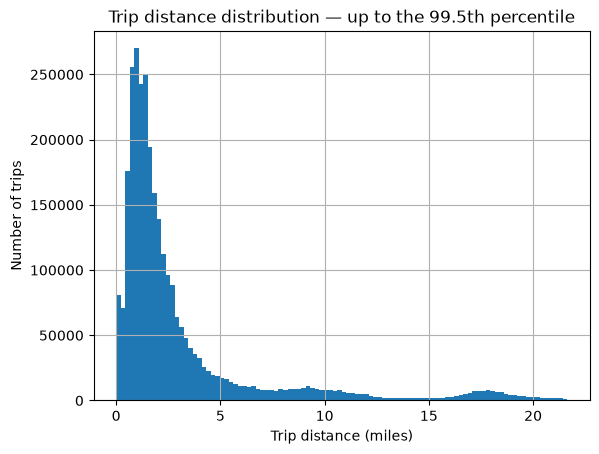

In [16]:
distance_plot_limit = df["trip_distance"].quantile(0.995)

df.loc[
    df["trip_distance"].between(0, distance_plot_limit),
    "trip_distance",
].hist(bins=100)

plt.title("Trip distance distribution — up to the 99.5th percentile")
plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.show()


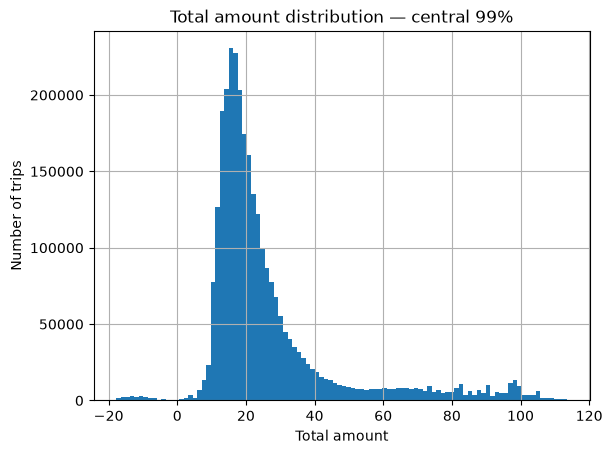

In [17]:
total_lower = df["total_amount"].quantile(0.005)
total_upper = df["total_amount"].quantile(0.995)

df.loc[
    df["total_amount"].between(total_lower, total_upper),
    "total_amount",
].hist(bins=100)

plt.title("Total amount distribution — central 99%")
plt.xlabel("Total amount")
plt.ylabel("Number of trips")
plt.show()


### 5.3 Monetary values

**Observation**

Negative values occur in several monetary fields and often share the same
row. A separate test is needed to distinguish a coherent signed
transaction population from isolated field corruption.

**Hypothesis H2**

Rows with both negative `fare_amount` and negative `total_amount` form a
coherent signed transaction population. Payment type may provide context,
but it cannot prove whether an individual row represents a dispute,
reversal, correction or another business event.

**Hypothesis H3**

Negative tips may form an independent tip-only correction population.
This is tested directly rather than inferred from the sign of `tip_amount`.


In [18]:
negative_fare = df["fare_amount"] < 0
negative_total = df["total_amount"] < 0
negative_tip = df["tip_amount"] < 0

negative_populations = pd.Series({
    "fare < 0 and total < 0": (negative_fare & negative_total).sum(),
    "fare < 0 and total >= 0": (negative_fare & ~negative_total).sum(),
    "fare >= 0 and total < 0": (~negative_fare & negative_total).sum(),
    "tip < 0 with fare < 0 and total < 0": (
        negative_tip & negative_fare & negative_total
    ).sum(),
    "tip < 0 only": (
        negative_tip & ~negative_fare & ~negative_total
    ).sum(),
})

payment_type_by_population = pd.DataFrame({
    "negative_fare_and_total": (
        df.loc[negative_fare & negative_total, "payment_type"]
        .map(PAYMENT_TYPES).value_counts()
    ),
    "negative_fare_or_total_mismatch": (
        df.loc[negative_fare ^ negative_total, "payment_type"]
        .map(PAYMENT_TYPES).value_counts()
    ),
    "negative_tip_only": (
        df.loc[
            negative_tip & ~negative_fare & ~negative_total,
            "payment_type",
        ].map(PAYMENT_TYPES).value_counts()
    ),
}).fillna(0).astype(int)

negative_populations


fare < 0 and total < 0                 35384
fare < 0 and total >= 0                 2064
fare >= 0 and total < 0                  120
tip < 0 with fare < 0 and total < 0      102
tip < 0 only                               0
dtype: int64

In [19]:
payment_type_by_population


,negative_fare_and_total,negative_fare_or_total_mismatch,negative_tip_only
payment_type,,,
Cash,8208,118,0
Credit card,28,1,0
Dispute,21406,0,0
Flex Fare,2,2064,0
No charge,5740,1,0


**Conclusion H2 - supported; H3 - rejected**

There are 35,384 rows with both a negative fare and a negative total.
This population is dominated by documented payment categories associated
with disputes, cash and no-charge trips. The values should be retained as
signed source transactions and must not be converted to positive numbers.
The exact business event cannot be proven from these fields alone, so the
neutral label `is_negative_transaction` is used.

There are 2,064 rows with a negative fare but non-negative total and 120
with a non-negative fare but negative total. These sign mismatches form a
separate quality-monitoring population; the first group consists entirely
of Flex Fare records.

H3 is rejected. All 102 negative-tip rows also have a negative fare and a
negative total. No independent negative-tip-only population exists in this
file, so a separate tip-correction rule is not justified.


#### Monetary reconciliation - Hypothesis H4

The dictionary defines `total_amount` as the total charged to the passenger
and `extra` as miscellaneous extras and surcharges. It does not state that
the listed monetary fields must always form a mutually exclusive arithmetic
decomposition.

**Hypothesis H4**

Naively summing every monetary field may reconcile differently by vendor,
because a vendor can include a surcharge in `extra` while also reporting it
in a dedicated field. Reconciliation must therefore be evaluated by
`VendorID` before defining any mismatch flag.


In [20]:
amount_components = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
]

complete_amount_mask = df[amount_components].notna().all(axis=1)
complete_component_sum = df[amount_components].sum(
    axis=1,
    min_count=len(amount_components),
)
amount_residual = (
    df["total_amount"] - complete_component_sum
).round(2)

reconciliation_rows = []
for vendor_id in sorted(df["VendorID"].unique()):
    vendor_mask = complete_amount_mask & df["VendorID"].eq(vendor_id)
    residual = amount_residual.loc[vendor_mask]
    row_count = len(residual)
    reconciliation_rows.append({
        "VendorID": int(vendor_id),
        "complete_rows": row_count,
        "matching_within_1_cent": int(residual.abs().le(0.01).sum()),
        "matching_percentage": (
            round(residual.abs().le(0.01).mean() * 100, 4)
            if row_count else np.nan
        ),
        "median_residual": residual.median() if row_count else np.nan,
        "maximum_absolute_residual": (
            residual.abs().max() if row_count else np.nan
        ),
    })

reconciliation_by_vendor = pd.DataFrame(
    reconciliation_rows
).set_index("VendorID")

top_residuals_by_vendor = (
    pd.DataFrame({
        "VendorID": df.loc[complete_amount_mask, "VendorID"],
        "amount_residual": amount_residual.loc[complete_amount_mask],
    })
    .value_counts()
    .rename("count")
    .groupby(level="VendorID")
    .head(5)
    .to_frame()
)

display(reconciliation_by_vendor)
top_residuals_by_vendor


,complete_rows,matching_within_1_cent,matching_percentage,median_residual,maximum_absolute_residual
VendorID,,,,,
1,681277,49797,7.3094,-2.5,4.25
2,2143185,2138750,99.7931,0.0,2.50
6,0,0,NaN,NaN,NaN


count
VendorID amount_residual         
2         0.00            2138750
1        -2.50             590940
          0.00              49797
         -4.25              22451
         -1.75              18086
2         2.50               4244
         -2.50                105
         -1.75                 63
          1.95                 23
1        -1.00                  2

In [21]:
known_component_sum = df[amount_components].sum(axis=1, skipna=True)
flex_fare_residual = (
    df["total_amount"] - known_component_sum
).round(2)

flex_fare_residual_counts = (
    flex_fare_residual.loc[flex_fare_mask]
    .value_counts()
    .rename("count")
    .to_frame()
)
flex_fare_residual_counts["percentage"] = (
    flex_fare_residual_counts["count"]
    .div(flex_fare_mask.sum())
    .mul(100)
    .round(4)
)

flex_fare_residual_counts.head(15)


,count,percentage
2.50,125088,89.2453
0.00,14239,10.1590
4.50,792,0.5651
2.00,42,0.0300
1.75,1,0.0007


**Conclusion H4 - supported**

The naive reconciliation rule is vendor-dependent and must not be used as
a universal data-quality flag:

- Vendor 1 reconciles within one cent for only 7.31% of complete rows;
  its dominant residual is `-2.50`, consistent with overlap between
  `extra` and a separately reported surcharge.
- Vendor 2 reconciles within one cent for 99.79% of complete rows.
- Vendor 6 has no complete monetary rows because all 260 records belong to
  the Flex Fare segment.

Therefore, the earlier general `is_total_mismatch` rule is rejected. The
residual remains a diagnostic measure only until a vendor-aware financial
contract is established.

Within the Flex Fare segment, 89.25% of rows have a residual of `2.50`
when only available components are summed. This confirms that missing
surcharge fields cannot safely be interpreted or imputed as zero.


#### Derived diagnostic columns

The following cells add temporary columns to `df` for subsequent EDA checks.
They do not modify the raw source file.


In [22]:
# Derived fields used only by later EDA checks.
df["is_flex_fare_record"] = flex_fare_mask
df["is_negative_transaction"] = df["total_amount"] < 0
df["amount_residual_diagnostic"] = amount_residual


### 5.4 Dates, duration, distance and speed

**Hypotheses**

- Negative or zero duration is temporally invalid.
- A concentration of durations close to 24 hours may indicate a
  timestamp or trip-closing problem.
- Extremely high speed is caused by implausible duration and/or distance
  values rather than an error in the speed formula.
- The Flex Fare segment may have a different distance-quality profile.


In [23]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"]
    - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

duration_quantiles = df["trip_duration_minutes"].quantile(
    [0, 0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999, 1]
)

duration_checks = pd.Series({
    "duration < 0": (df["trip_duration_minutes"] < 0).sum(),
    "duration = 0": df["trip_duration_minutes"].eq(0).sum(),
    "0 < duration < 1 minute": df["trip_duration_minutes"].between(
        0, 1, inclusive="neither"
    ).sum(),
    "duration > 6 hours": (df["trip_duration_minutes"] > 360).sum(),
    "duration > 24 hours": (df["trip_duration_minutes"] > 1440).sum(),
})

duration_quantiles


0.000     -13.566667
0.001       0.066667
0.010       0.600000
0.250       7.150000
0.500      11.633333
0.750      18.683333
0.990      60.450000
0.999     114.871033
1.000    9455.400000
Name: trip_duration_minutes, dtype: float64

In [24]:
duration_checks


duration < 0                  56
duration = 0                 814
0 < duration < 1 minute    34251
duration > 6 hours          1772
duration > 24 hours           16
dtype: int64

In [25]:
REPORTING_START = pd.Timestamp("2024-01-01")
REPORTING_END = pd.Timestamp("2024-02-01")
BOUNDARY_MARGIN = pd.Timedelta(days=7)
ANCIENT_CUTOFF = pd.Timestamp("2023-01-01")
PROCESSING_TIME = pd.Timestamp.now()

pickup = df["tpep_pickup_datetime"]
outside_reporting_month = (
    (pickup < REPORTING_START) | (pickup >= REPORTING_END)
)
boundary_dates = outside_reporting_month & (
    (
        (pickup >= REPORTING_START - BOUNDARY_MARGIN)
        & (pickup < REPORTING_START)
    )
    | (
        (pickup >= REPORTING_END)
        & (pickup < REPORTING_END + BOUNDARY_MARGIN)
    )
)
ancient_or_untrustworthy_dates = (
    pickup.isna()
    | (pickup < ANCIENT_CUTOFF)
    | (pickup > PROCESSING_TIME)
)
unexplained_outside_dates = (
    outside_reporting_month
    & ~boundary_dates
    & ~ancient_or_untrustworthy_dates
)

date_checks = pd.Series({
    "earliest pickup": pickup.min(),
    "latest pickup": pickup.max(),
    "pickups outside January 2024": outside_reporting_month.sum(),
    "boundary-date candidates": boundary_dates.sum(),
    "untrustworthy-date candidates": ancient_or_untrustworthy_dates.sum(),
    "unexplained outside dates": unexplained_outside_dates.sum(),
})

date_checks


earliest pickup                  2002-12-31 22:59:39
latest pickup                    2024-02-01 00:01:15
pickups outside January 2024                      18
boundary-date candidates                          13
untrustworthy-date candidates                      5
unexplained outside dates                          0
dtype: object

In [26]:
date_issue_type = pd.Series("inside reporting month", index=df.index)
date_issue_type.loc[boundary_dates] = "month-boundary record"
date_issue_type.loc[ancient_or_untrustworthy_dates] = "ancient/untrustworthy date"
date_issue_type.loc[unexplained_outside_dates] = "other outside-month date"

outside_reporting_records = df.loc[
    outside_reporting_month,
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "total_amount",
    ],
].assign(date_issue_type=date_issue_type.loc[outside_reporting_month])

outside_reporting_records.sort_values("tpep_pickup_datetime")


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,total_amount,date_issue_type
53119,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,-10.50,ancient/untrustworthy date
53120,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,10.50,ancient/untrustworthy date
2558056,2009-01-01 00:24:09,2009-01-01 01:13:00,48.850000,10.88,68.29,ancient/untrustworthy date
1230169,2009-01-01 23:30:39,2009-01-02 00:01:39,31.000000,10.99,50.00,ancient/untrustworthy date
10915,2009-01-01 23:58:40,2009-01-02 00:01:40,3.000000,0.46,9.40,ancient/untrustworthy date
369,2023-12-31 23:39:17,2023-12-31 23:42:00,2.716667,0.47,10.10,month-boundary record
753,2023-12-31 23:41:02,2023-12-31 23:48:03,7.016667,0.40,12.20,month-boundary record
3176,2023-12-31 23:47:28,2023-12-31 23:57:07,9.650000,1.44,18.84,month-boundary record
2985,2023-12-31 23:49:12,2024-01-01 00:04:32,15.333333,3.14,28.60,month-boundary record
8628,2023-12-31 23:54:27,2024-01-01 00:13:12,18.750000,7.70,45.72,month-boundary record


In [27]:
valid_duration_mask = df["trip_duration_minutes"] > 0
df["average_speed_mph"] = np.nan
df.loc[valid_duration_mask, "average_speed_mph"] = (
    df.loc[valid_duration_mask, "trip_distance"]
    / (df.loc[valid_duration_mask, "trip_duration_minutes"] / 60)
)

speed_quantiles = df["average_speed_mph"].quantile(
    [0, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1]
)

speed_checks = pd.Series({
    "speed = 0": df["average_speed_mph"].eq(0).sum(),
    "speed > 80 mph": (df["average_speed_mph"] > 80).sum(),
    "speed > 100 mph": (df["average_speed_mph"] > 100).sum(),
    "speed > 200 mph": (df["average_speed_mph"] > 200).sum(),
})

speed_quantiles.round(2)


0.000          0.00
0.250          7.24
0.500          9.57
0.750         13.03
0.950         26.11
0.990         37.01
0.999         49.02
1.000    1443333.69
Name: average_speed_mph, dtype: float64

In [28]:
speed_checks


speed = 0          59613
speed > 80 mph      1107
speed > 100 mph     1024
speed > 200 mph      830
dtype: int64

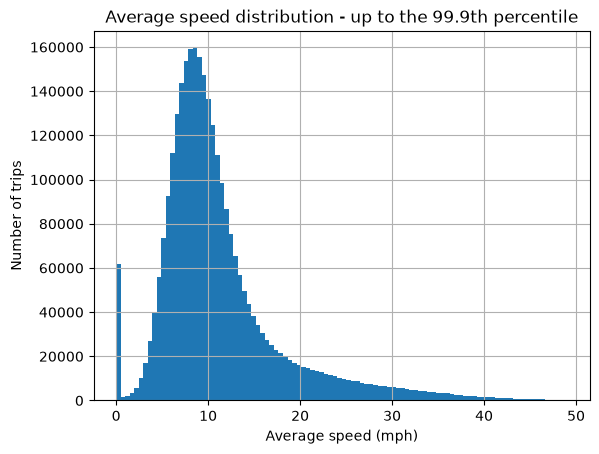

In [29]:
speed_plot_limit = df["average_speed_mph"].quantile(0.999)

df.loc[
    df["average_speed_mph"].between(0, speed_plot_limit),
    "average_speed_mph",
].hist(bins=100)

plt.title("Average speed distribution - up to the 99.9th percentile")
plt.xlabel("Average speed (mph)")
plt.ylabel("Number of trips")
plt.show()


In [30]:
high_speed_mask = df["average_speed_mph"] > 80

high_speed_diagnostics = pd.Series({
    "all high-speed records": high_speed_mask.sum(),
    "duration < 1 minute": (
        high_speed_mask & (df["trip_duration_minutes"] < 1)
    ).sum(),
    "trip_distance > 100 miles": (
        high_speed_mask & (df["trip_distance"] > 100)
    ).sum(),
    "trip_distance > 500 miles": (
        high_speed_mask & (df["trip_distance"] > 500)
    ).sum(),
    "Flex Fare group": (
        high_speed_mask & flex_fare_mask
    ).sum(),
    "negative transaction": (
        high_speed_mask & df["is_negative_transaction"]
    ).sum(),
})

high_speed_diagnostics


all high-speed records       1107
duration < 1 minute           977
trip_distance > 100 miles      30
trip_distance > 500 miles      25
Flex Fare group                67
negative transaction            8
dtype: int64

In [31]:
df.loc[
    df["average_speed_mph"].notna(),
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "average_speed_mph",
        "fare_amount",
        "total_amount",
        "is_flex_fare_record",
    ],
].sort_values("average_speed_mph", ascending=False).head(20)


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,average_speed_mph,fare_amount,total_amount,is_flex_fare_record
2958079,2024-01-30 06:37:00,2024-01-30 06:50:00,13.0,312722.30,1.443334e+06,14.46,22.15,True
2854947,2024-01-09 07:13:00,2024-01-09 07:17:00,4.0,59076.43,8.861465e+05,13.82,23.17,True
2920143,2024-01-21 11:58:00,2024-01-21 12:12:00,14.0,72975.97,3.127542e+05,12.70,20.04,True
2868605,2024-01-12 05:16:00,2024-01-12 05:26:00,10.0,51619.36,3.097162e+05,16.17,24.20,True
2865355,2024-01-11 07:41:00,2024-01-11 07:48:00,7.0,33934.01,2.908629e+05,13.82,19.60,True
2931119,2024-01-24 12:26:00,2024-01-24 12:42:00,16.0,58298.51,2.186194e+05,12.94,18.63,True
2934895,2024-01-25 08:39:00,2024-01-25 09:06:00,27.0,97793.92,2.173198e+05,29.71,36.31,True
2911232,2024-01-20 08:01:00,2024-01-20 08:26:00,25.0,82015.45,1.968371e+05,16.56,21.56,True
2875656,2024-01-13 14:00:00,2024-01-13 14:13:00,13.0,41123.32,1.897999e+05,14.57,18.57,True
2875730,2024-01-13 15:50:00,2024-01-13 16:05:00,15.0,38131.83,1.525273e+05,19.39,29.24,True


In [32]:
duration_ranges = pd.cut(
    df["trip_duration_minutes"],
    bins=[
        float("-inf"), 0, 1, 360, 1200, 1380, 1440, float("inf")
    ],
    labels=[
        "<= 0 min",
        "0-1 min",
        "1 min-6 h",
        "6-20 h",
        "20-23 h",
        "23-24 h",
        "> 24 h",
    ],
    right=True,
)

duration_range_counts = duration_ranges.value_counts().sort_index()
duration_range_counts


trip_duration_minutes
<= 0 min         870
0-1 min        34543
1 min-6 h    2927439
6-20 h           304
20-23 h          136
23-24 h         1316
> 24 h            16
Name: count, dtype: int64

In [33]:
near_24h_mask = df["trip_duration_minutes"].between(
    1380, 1440, inclusive="left"
)
hypothetical_duration = 1440 - df.loc[
    near_24h_mask, "trip_duration_minutes"
]
hypothetical_speed = df.loc[near_24h_mask, "trip_distance"] / (
    hypothetical_duration / 60
)

near_24h_diagnostic = pd.DataFrame({
    "original_duration_minutes": df.loc[
        near_24h_mask, "trip_duration_minutes"
    ],
    "hypothetical_duration_minutes": hypothetical_duration,
    "trip_distance": df.loc[near_24h_mask, "trip_distance"],
    "hypothetical_speed_mph": hypothetical_speed,
    "fare_amount": df.loc[near_24h_mask, "fare_amount"],
    "total_amount": df.loc[near_24h_mask, "total_amount"],
})

near_24h_checks = pd.Series({
    "records": len(near_24h_diagnostic),
    "hypothetical duration <= 0": (
        near_24h_diagnostic["hypothetical_duration_minutes"] <= 0
    ).sum(),
    "hypothetical speed <= 80 mph": (
        near_24h_diagnostic["hypothetical_speed_mph"].between(0, 80)
    ).sum(),
    "hypothetical speed > 80 mph": (
        near_24h_diagnostic["hypothetical_speed_mph"] > 80
    ).sum(),
})

display(near_24h_diagnostic.describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).T)
near_24h_checks


,count,mean,std,min,1%,25%,50%,75%,99%,max
original_duration_minutes,1316.0,1422.336208,14.829254,1380.066667,1381.444167,1413.741667,1426.700000,1434.187500,1439.359167,1439.983333
hypothetical_duration_minutes,1316.0,17.663792,14.829254,0.016667,0.640833,5.812500,13.300000,26.258333,58.555833,59.933333
trip_distance,1316.0,2.905585,3.508812,0.000000,0.306000,1.080000,1.845000,3.110000,18.237000,26.700000
hypothetical_speed_mph,1316.0,31.994574,221.928853,0.000000,0.584726,3.824627,9.345465,25.668345,261.483429,7653.600000
fare_amount,1316.0,17.902964,14.527585,-7.200000,4.400000,9.300000,13.500000,20.500000,70.765000,129.000000
total_amount,1316.0,24.908435,16.861551,-13.700000,9.100000,15.400000,20.300000,28.000000,98.915000,132.250000


records                         1316
hypothetical duration <= 0         0
hypothetical speed <= 80 mph    1229
hypothetical speed > 80 mph       87
dtype: int64

In [34]:
distance_by_group = pd.crosstab(
    record_group,
    pd.cut(
        df["trip_distance"],
        bins=[float("-inf"), 0, 50, 100, 500, float("inf")],
        labels=["<= 0", "0-50", "50-100", "100-500", "> 500"],
    ),
)

distance_by_group_percentages = (
    distance_by_group.div(distance_by_group.sum(axis=1), axis=0)
    .mul(100)
    .round(4)
)

distance_by_group_percentages


trip_distance,<= 0,0-50,50-100,100-500,> 500
record_group,,,,,
flex_fare_group,16.2847,83.6989,0.0014,0.0007,0.0143
standard_group,1.3293,98.6569,0.0124,0.0012,0.0002


**Conclusions: dates, duration, distance and speed**

The typical part of the data is plausible: median duration is 11.63
minutes, median speed is 9.57 mph and the 99th-percentile speed is 37.01
mph. The extreme tail is caused by identifiable quality problems.

- There are 56 negative-duration and 814 zero-duration rows. They cannot
  support ordinary duration or speed analysis.
- Of 1,772 durations above six hours, 1,316 fall between 23 and 24 hours.
  Taking the diagnostic complement to 24 hours gives a median duration of
  13.3 minutes and median speed of 9.35 mph. This supports a systematic
  timestamp anomaly but does not justify automatic timestamp correction.
- There are 1,107 rows above 80 mph; 977 also have duration below one
  minute. The largest speeds additionally expose clearly corrupted
  distances, including tens or hundreds of thousands of miles.
- Non-positive distance occurs in 16.28% of Flex Fare rows versus 1.33%
  of standard rows. Extreme distances above 500 miles are also
  disproportionately concentrated in Flex Fare.
- Eighteen pickups fall outside January 2024: 13 are plausible
  month-boundary records and five have ancient 2002/2009 timestamps.

Source timestamps and distances are not overwritten. The five rows with
untrustworthy 2002/2009 pickup dates are routed to `rejected`; other
affected rows remain in `processed` with quality flags.


### 5.5 Duplicate checks


In [35]:
exact_duplicate_rows = df.duplicated(keep=False).sum()
exact_duplicate_removable = df.duplicated(keep="first").sum()

pd.Series({
    "rows participating in exact duplicates": exact_duplicate_rows,
    "exact duplicate rows removable": exact_duplicate_removable,
})


rows participating in exact duplicates    0
exact duplicate rows removable            0
dtype: int64

In [36]:
trip_identity_columns = [
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "fare_amount",
    "total_amount",
]

business_duplicate_rows = df.duplicated(
    subset=trip_identity_columns,
    keep=False,
).sum()
business_duplicate_removable = df.duplicated(
    subset=trip_identity_columns,
    keep="first",
).sum()

pd.Series({
    "rows participating in possible business duplicates": business_duplicate_rows,
    "possible business duplicate rows removable": business_duplicate_removable,
})


rows participating in possible business duplicates    0
possible business duplicate rows removable            0
dtype: int64

No exact duplicate rows and no duplicates under the selected trip-identity
fields were found. Source-level duplicate removal is therefore not
justified for this file.

A production ingestion process should still enforce idempotency so that
retries cannot append the same source file twice. That operational control
is separate from applying `drop_duplicates()` to the trip records.


## 6. Final findings

The EDA produced the following evidence-backed findings:

1. All 140,162 `payment_type = 0` rows are Flex Fare records with the same
   five missing fields. They form a contiguous final segment but should not
   be rejected as a group.
2. All observed non-null provider, rate, payment and store-and-forward
   codes belong to the official TLC domains. In particular,
   `VendorID = 6`, `RatecodeID = 99` and `payment_type = 0` are documented.
3. The 35,384 rows with negative fare and total form a coherent signed
   transaction population. H3 is rejected because all 102 negative tips
   belong to this population; there is no tip-only group.
4. Naive monetary reconciliation is vendor-dependent: 7.31% of complete
   Vendor 1 rows reconcile within one cent versus 99.79% for Vendor 2.
   A universal `is_total_mismatch` flag is therefore not valid.
5. Missing Flex Fare surcharge values must remain missing. In 89.25% of
   these rows, the residual to `total_amount` is exactly 2.50.
6. Time and distance anomalies are concentrated in small, identifiable
   groups: 870 non-positive durations, 1,316 near-24-hour durations, 1,107
   speeds above 80 mph, 59 distances above 100 miles and 18 pickups outside
   the January reporting month.
7. Five records with 2002/2009 pickup dates violate the trusted timestamp
   contract and are routed to `rejected`. The remaining 13 month-boundary
   records stay in `processed` with `is_outside_reporting_month`.
8. No exact or tested business duplicates were found.

These findings are translated into explicit retain, flag and analytical
exclusion decisions in `table_of_cleansing.md`. Exploratory calculations
and plots stay in this notebook; the later production pipeline will
implement only stable validations, derived fields and quality rules.


## 7. Cleaning handoff

The notebook does not mutate or delete source records as a final cleaning
step. Its output is the evidence used to define the cleaning contract in
[`table_of_cleansing.md`](../docs/table_of_cleansing.md).

The next implementation stage should preserve an immutable raw layer,
create `processed` and `rejected` outputs with lineage and quality fields,
and enforce `raw rows = processed rows + rejected rows`. EDA-only tables,
plots and hypotheses do not belong in the recurring pipeline.
